# ****# **🚗 CO₂ Emisyon Tahmini (Regresyon Projesi)******

Bu projede Kaggle’daki “CO2 Emission by Vehicles” veri setini kullanarak araç özelliklerinden CO2 Emissions (g/km) değerini tahmin eden bir regresyon modeli geliştireceğiz.

Plan:

* Feature engineering ile veri setini modellemeye hazır hale getirme

* EDA ile önemli değişkenleri belirleme

* Birden fazla regresyon modeli ile eğitim ve R² karşılaştırması

* En iyi model üzerinde hyperparameter tuning ile performansı artırma

Hedef değişken: CO2 Emissions(g/km)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("CO2 Emissions_Canada.csv")

In [3]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [5]:
df[df.duplicated()]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
1075,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
1076,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
1081,ALFA ROMEO,4C,TWO-SEATER,1.8,4,AM6,Z,9.7,6.9,8.4,34,193
1082,ASTON MARTIN,DB9,MINICOMPACT,5.9,12,A6,Z,18.0,12.6,15.6,18,359
1084,ASTON MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,AM7,Z,17.4,11.3,14.7,19,338
...,...,...,...,...,...,...,...,...,...,...,...,...
7356,TOYOTA,Tundra,PICKUP TRUCK - STANDARD,5.7,8,AS6,X,17.7,13.6,15.9,18,371
7365,VOLKSWAGEN,Golf GTI,COMPACT,2.0,4,M6,X,9.8,7.3,8.7,32,203
7366,VOLKSWAGEN,Jetta,COMPACT,1.4,4,AS8,X,7.8,5.9,7.0,40,162
7367,VOLKSWAGEN,Jetta,COMPACT,1.4,4,M6,X,7.9,5.9,7.0,40,163


In [3]:
df = df.drop_duplicates(keep="first", ignore_index = True)

In [4]:
df[df.duplicated()]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)


In [7]:
df['Make'].nunique()

42

In [8]:
df['Model'].nunique()

2053

### **🧹 Make ve Model Sütunlarını Drop Etme Kararı**

Veri setinde Make (marka) ve özellikle Model (2053 farklı değer) sütunları çok yüksek kardinaliteye sahip. Bu sütunları one-hot encoding ile dönüştürmek:

* Çok fazla yeni sütun üretir (boyut şişmesi),

* Overfitting riskini artırabilir,

* Eğitim ve bellek maliyetini yükseltir.

Ayrıca emisyonu doğrudan açıklayan Engine Size, Cylinders, Fuel Consumption, Transmission, Fuel Type gibi daha anlamlı teknik değişkenler zaten mevcut olduğu için, başlangıç (baseline) modelinde Make ve Model sütunlarını modeli sadeleştirmek ve verimli ilerlemek adına veri setinden çıkaracağız.

In [5]:
df.drop(['Make', 'Model'], axis=1, inplace=True)

In [10]:
df.head()

,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [11]:
df['Transmission'].unique()

array(['AS5', 'M6', 'AV7', 'AS6', 'AM6', 'A6', 'AM7', 'AV8', 'AS8', 'A7',
       'A8', 'M7', 'A4', 'M5', 'AV', 'A5', 'AS7', 'A9', 'AS9', 'AV6',
       'AS4', 'AM5', 'AM8', 'AM9', 'AS10', 'A10', 'AV10'], dtype=object)

### **⚙️ Transmission Sütununu İkili Değişkene Dönüştürme**

Transmission sütunu (örn. AS5, M6, AM7) çok sayıda alt kategori içeriyor. Bu kodların başındaki harf vites tipini özetler:

* A → otomatik / otomatik varyantları

* M → manuel

Vites sayısı veya otomatik alt türleri emisyonu sınırlı ölçüde etkileyebilirken, manuel vs otomatik ayrımı sürüş dinamikleri üzerinden emisyon üzerinde daha belirgin bir etki yaratabilir. Bu nedenle sütunu basitleştirerek modele daha uygun hale getiriyoruz:

* 0 → Manuel

* 1 → Otomatik

In [6]:
df["Transmission_bin"] = (
    df["Transmission"].astype(str).str.strip().str[0].map({"A": 1, "M": 0})
)

# Kontrol: mapping sonrası boş kalan var mı?
missing = df["Transmission_bin"].isna().sum()
print("Transmission_bin NaN sayısı:", missing)

# İstersen NaN'leri incelemek için:
if missing > 0:
    print("Bilinmeyen Transmission kodları:", df.loc[df["Transmission_bin"].isna(), "Transmission"].unique())


Transmission_bin NaN sayısı: 0


In [7]:
df.drop('Transmission', axis=1, inplace=True)

In [14]:
df.head()

,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Transmission_bin
0,COMPACT,2.0,4,Z,9.9,6.7,8.5,33,196,1
1,COMPACT,2.4,4,Z,11.2,7.7,9.6,29,221,0
2,COMPACT,1.5,4,Z,6.0,5.8,5.9,48,136,1
3,SUV - SMALL,3.5,6,Z,12.7,9.1,11.1,25,255,1
4,SUV - SMALL,3.5,6,Z,12.1,8.7,10.6,27,244,1


In [15]:
df['Vehicle Class'].unique()

array(['COMPACT', 'SUV - SMALL', 'MID-SIZE', 'TWO-SEATER', 'MINICOMPACT',
       'SUBCOMPACT', 'FULL-SIZE', 'STATION WAGON - SMALL',
       'SUV - STANDARD', 'VAN - CARGO', 'VAN - PASSENGER',
       'PICKUP TRUCK - STANDARD', 'MINIVAN', 'SPECIAL PURPOSE VEHICLE',
       'STATION WAGON - MID-SIZE', 'PICKUP TRUCK - SMALL'], dtype=object)

In [16]:
df['Fuel Type'].unique()

array(['Z', 'D', 'X', 'E', 'N'], dtype=object)

### **🔠 Kalan Kategorik Değişkenler**

Make ve Model sütunları çıkarıldıktan ve Transmission ikili formata dönüştürüldükten sonra veri setinde kalan kategorik sütunlar:

* Vehicle Class

* Fuel Type

Bu sütunlar az sayıda kategori içerdiği için, ilerleyen adımlarda modele uygun şekilde (ör. One-Hot Encoding veya uygun alternatifleri) dönüştürülerek eğitim sürecine dahil edilecektir.

### **🔥 Korelasyon Analizi ve Yakıt Tüketimi Sütunlarının Seçimi**

Yakıt tüketimine ait sayısal sütunların (City, Hwy, Comb) hedef değişken CO2 Emissions (g/km) ile korelasyonlarına baktığımızda bu değişkenlerin birbirleriyle çok yüksek korelasyonlu olduğunu görüyoruz. Bu durum aynı bilgiyi farklı sütunlarda tekrar etmek anlamına gelir ve model tarafında multicollinearity / gereksiz tekrar oluşturabilir.

Bu yüzden yakıt tüketimini en iyi özetleyen tek sütun olarak:

* ✅ Fuel Consumption Comb (L/100 km) bırakıldı

* ❌ Fuel Consumption City (L/100 km) drop edildi

* ❌ Fuel Consumption Hwy (L/100 km) drop edildi

Ek olarak Fuel Consumption Comb (mpg) sütunu, Comb (L/100 km) ile çok yüksek negatif korelasyona sahiptir çünkü aynı tüketim bilgisinin farklı bir ölçüm birimiyle (ters orantılı şekilde) ifade edilmesidir. Bu nedenle redundant (tekrarlı) bilgi taşıdığı için:

* ❌ Fuel Consumption Comb (mpg) da drop edildi

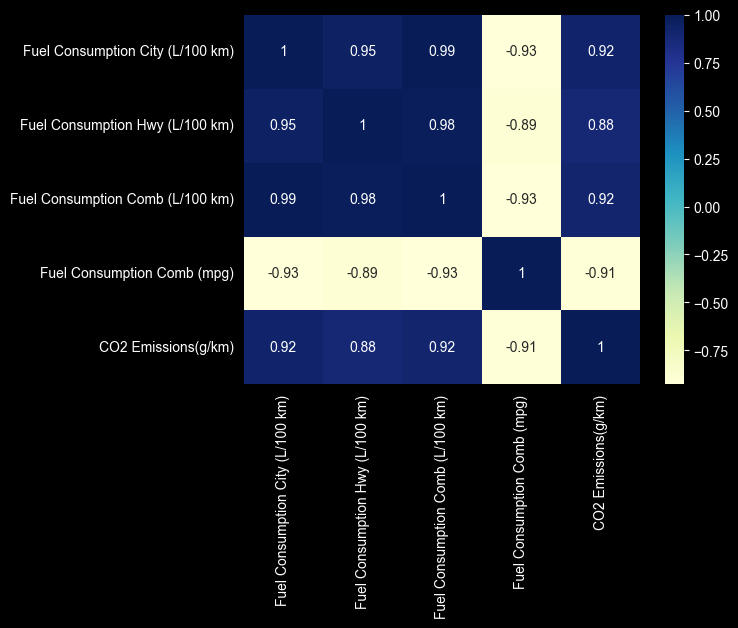

In [17]:
sns.heatmap(df[['Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']].corr(), annot=True, cmap="YlGnBu")
plt.show()

In [8]:
df.drop(['Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (mpg)'], axis=1, inplace=True)

In [19]:
df.tail()

,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km),Transmission_bin
6277,SUV - SMALL,2.0,4,Z,9.4,219,1
6278,SUV - SMALL,2.0,4,Z,9.9,232,1
6279,SUV - SMALL,2.0,4,Z,10.3,240,1
6280,SUV - STANDARD,2.0,4,Z,9.9,232,1
6281,SUV - STANDARD,2.0,4,Z,10.7,248,1


### **🔍 Keşifsel Veri Analizi (EDA)**

Modelleme aşamasına geçmeden önce veri setini daha iyi anlamak ve model performansını artıracak kararlar alabilmek için keşifsel veri analizi (EDA) çalışmaları gerçekleştirildi.

Bu süreçte:

* Veri tipleri ve eksik değer durumu incelendi

* Yüksek kardinaliteli kategorik değişkenler değerlendirildi ve gerekli sadeleştirmeler yapıldı

* Transmission bilgisi manuel (0) ve otomatik (1) olacak şekilde dönüştürüldü

* Yakıt tüketimi sütunları arasındaki yüksek korelasyon incelendi ve redundant değişkenler çıkarıldı

* Sayısal değişkenler arasındaki ilişkiler scatter ve korelasyon analizleri ile gözlemlendi

* Kategorik değişkenlerin hedef değişken üzerindeki etkileri görselleştirme teknikleri ile değerlendirildi

* Olası aykırı değerler ve dağılım yapıları kontrol edildi

Bu analizler sonucunda veri seti sadeleştirilmiş, bilgi tekrarları azaltılmış ve modelleme için daha uygun bir yapı oluşturulmuştur.

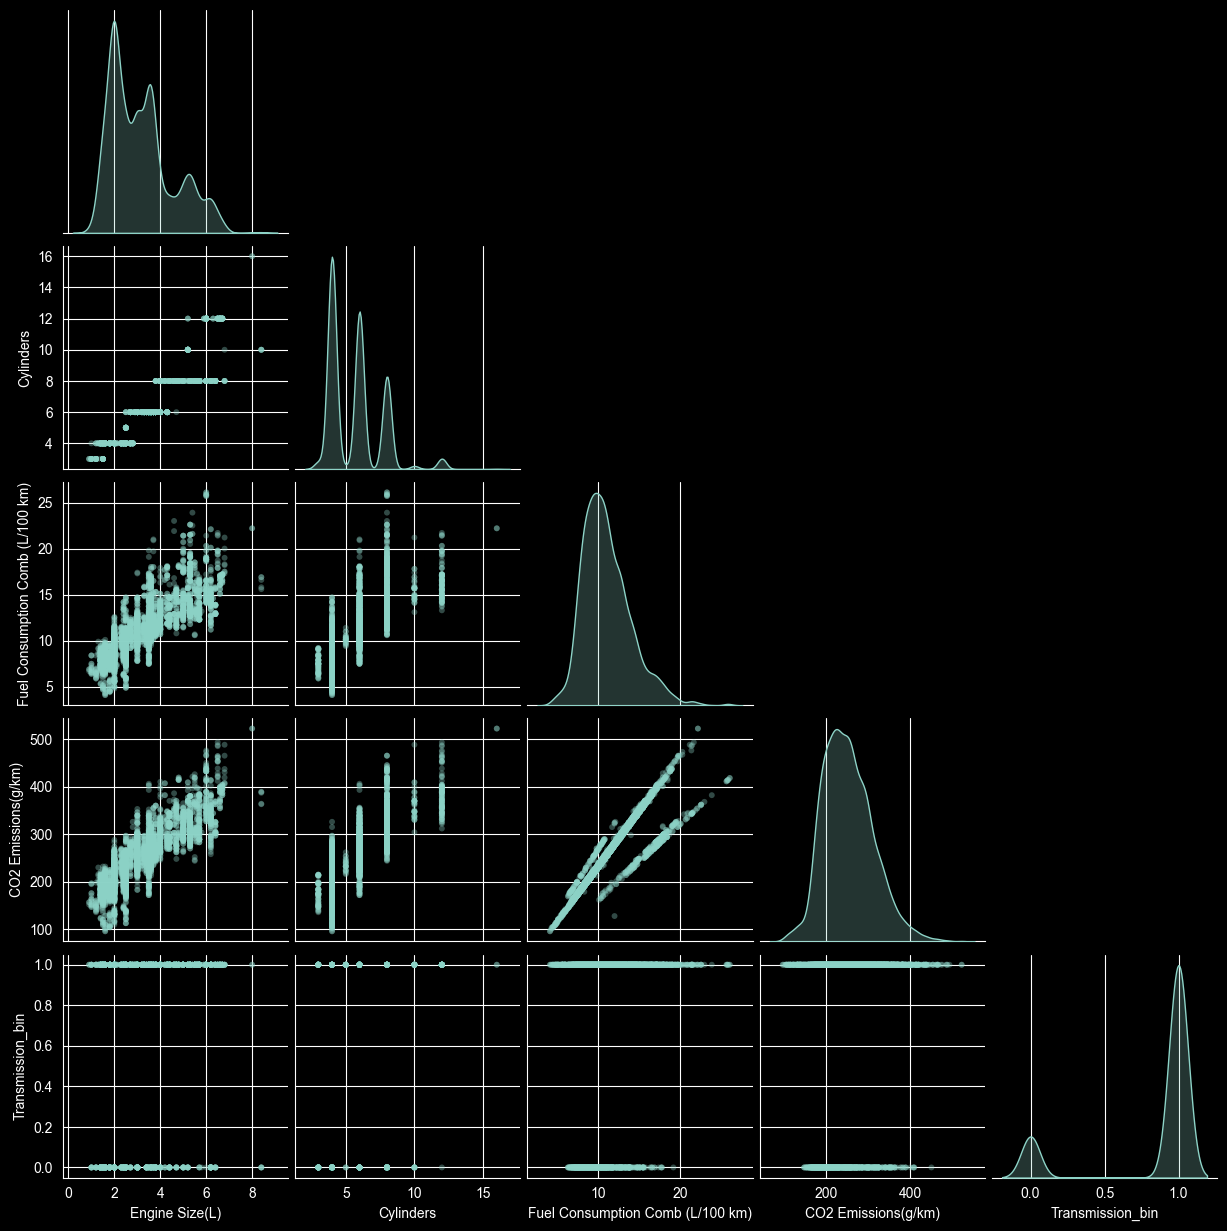

In [9]:
# Sadece numeric sütunlar (target dahil) ile pairplot
num_cols = df.select_dtypes(include="number").columns

sns.pairplot(
    df[num_cols],
    diag_kind="kde",      # diyagonalde dağılım
    corner=True,          # üst üçgeni çizmez (daha temiz)
    plot_kws={"alpha": 0.35, "s": 18, "edgecolor": "none"}
)

plt.show()

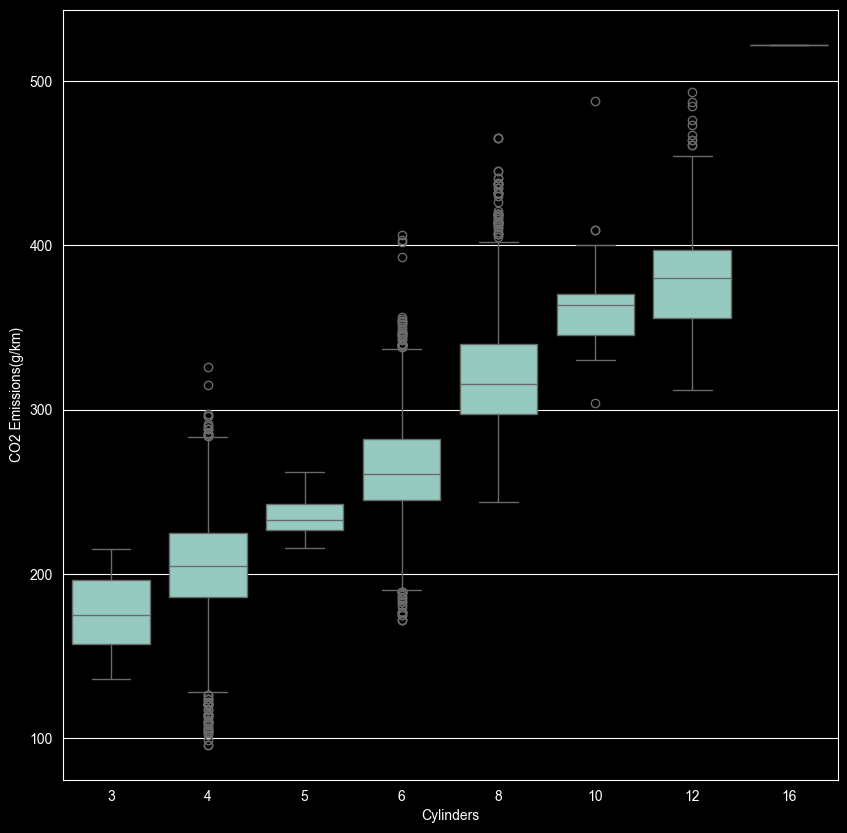

In [22]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='Cylinders', y='CO2 Emissions(g/km)')
plt.show()

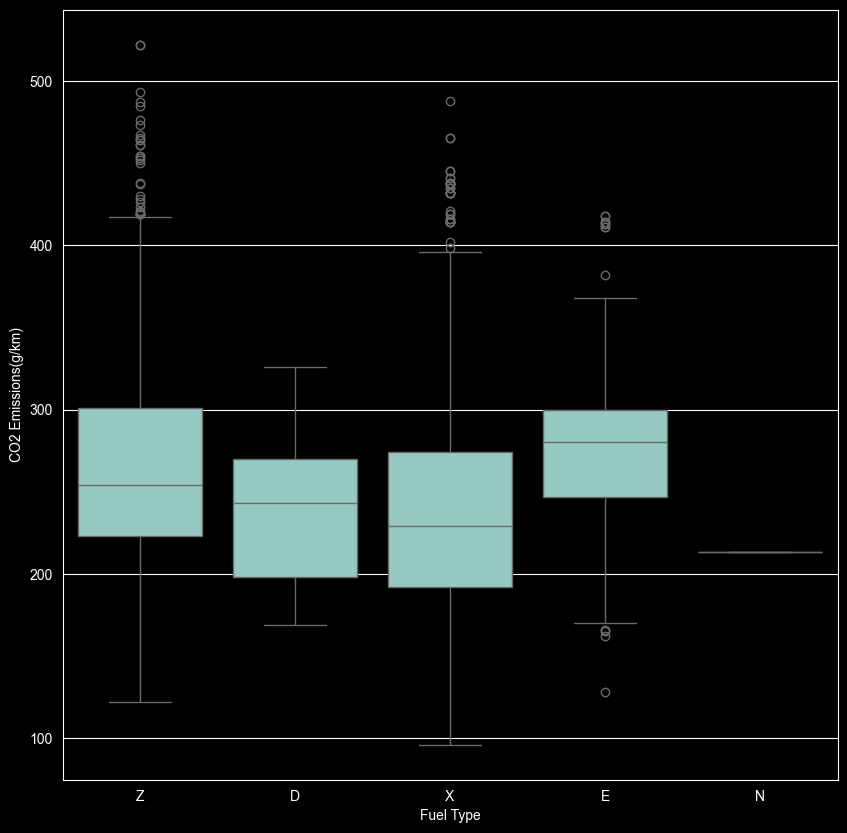

In [25]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='Fuel Type', y='CO2 Emissions(g/km)')
plt.show()

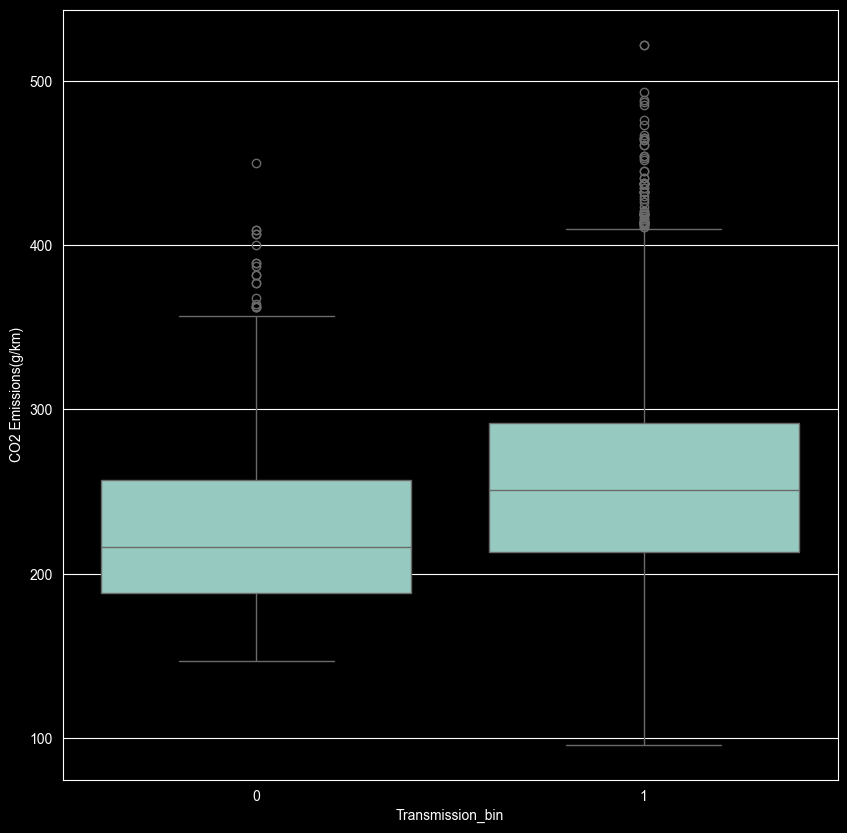

In [26]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='Transmission_bin', y='CO2 Emissions(g/km)')
plt.show()

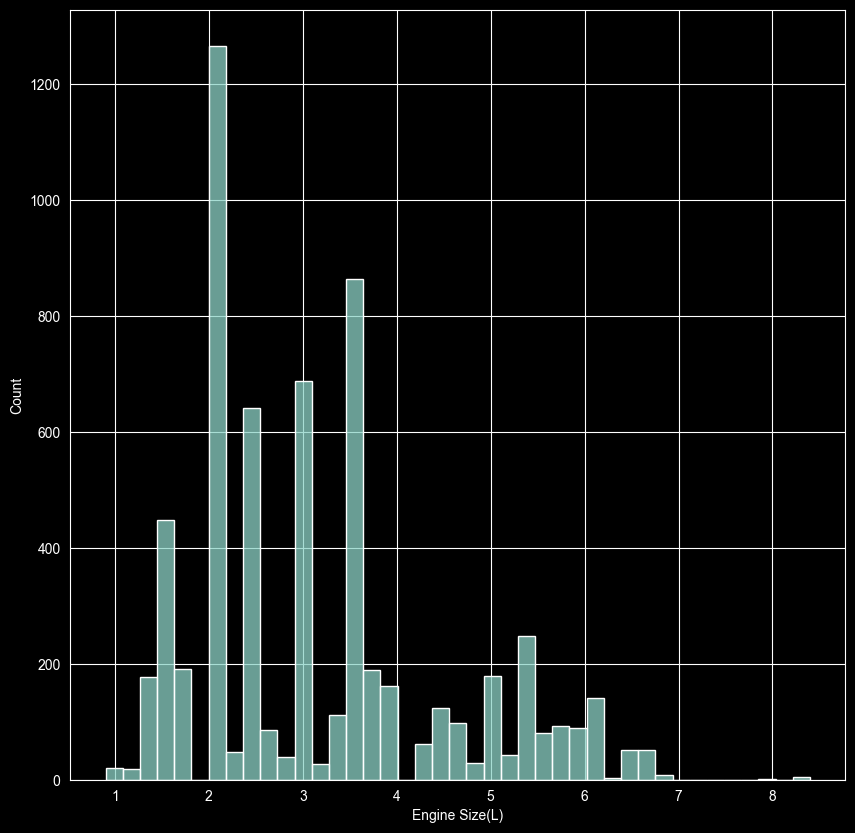

In [30]:
plt.figure(figsize=(10,10))
sns.histplot(data=df, x= 'Engine Size(L)')
plt.show()

In [31]:
df.corr(numeric_only=True)

,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km),Transmission_bin
Engine Size(L),1.000000,0.928843,0.820146,0.854802,0.196592
Cylinders,0.928843,1.000000,0.781099,0.834687,0.191491
Fuel Consumption Comb (L/100 km),0.820146,0.781099,1.000000,0.916840,0.179387
CO2 Emissions(g/km),0.854802,0.834687,0.916840,1.000000,0.169298
Transmission_bin,0.196592,0.191491,0.179387,0.169298,1.000000


### **🧩 Özellik–Hedef Ayrımı ve Train/Test Bölme**

Model eğitimine geçmeden önce hedef değişken (target) ile özellikleri (features) birbirinden ayırıyoruz:

* X (features): CO2 Emissions(g/km) dışındaki tüm sütunlar

* y (target): CO2 Emissions(g/km)

Ardından veri setini model performansını tarafsız şekilde ölçebilmek için %80 eğitim – %20 test olacak şekilde bölüyoruz (random_state=42 ile tekrarlanabilirlik sağlanır).

Son olarak preprocessing adımlarında kullanmak üzere sütun tiplerini ayırıyoruz:

* Kategorik sütunlar (cat_cols): Vehicle Class, Fuel Type

* Sayısal sütunlar (num_cols): Engine Size(L), Cylinders, Fuel Consumption Comb (L/100 km), Transmission_bin

Bu ayrım, ilerleyen aşamada ColumnTransformer ve Pipeline ile doğru encoding/ölçekleme işlemlerini uygulamayı kolaylaştırır.

In [10]:
X = df.drop('CO2 Emissions(g/km)', axis=1)
y = df['CO2 Emissions(g/km)']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
cat_cols = X.select_dtypes("object").columns.to_list()
num_cols = X.select_dtypes(include="number").columns.to_list()


In [13]:
cat_cols

['Vehicle Class', 'Fuel Type']

In [14]:
num_cols

['Engine Size(L)',
 'Cylinders',
 'Fuel Consumption Comb (L/100 km)',
 'Transmission_bin']

### **🏗️ Preprocessing Pipeline (Imputation + Scaling + One-Hot Encoding)**

Modelleme sürecinde veri sızıntısını (data leakage) önlemek ve tüm dönüşümleri eğitim/test ayrımına uygun şekilde otomatik uygulamak için Pipeline ve ColumnTransformer kullanıyoruz.

Bu yapı sayesinde:

* Sayısal sütunlar için:

    * Eksik değerler median ile doldurulur (SimpleImputer)

    * Ölçekleme yapılır (StandardScaler)

* Kategorik sütunlar için:

    * Eksik değerler en sık görülen değer ile doldurulur (most_frequent)

    * One-Hot Encoding uygulanır (OneHotEncoder)

    * handle_unknown="ignore" ile test sırasında görülmeyen kategoriler hata üretmeden yönetilir

    * drop="first" ile dummy trap riski azaltılır ve boyut şişmesi kontrol altında tutulur

Tüm bu adımlar preprocess nesnesi altında birleştirilerek, ilerleyen aşamada farklı modellerle kolayca tekrar kullanılabilecek modüler bir ön-işleme hattı oluşturulmuştur.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categoric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categoric_transformer, cat_cols)
    ],
    remainder="passthrough"
)

### **🤖 Regresyon Modellerinin Tanımlanması ve Değerlendirme Metrikleri**

Model performansını karşılaştırabilmek amacıyla farklı regresyon algoritmaları tanımlanmıştır:

* Linear Regression → doğrusal ilişki varsayımına dayalı temel model

* AdaBoost Regressor → zayıf öğrenicileri birleştirerek hatayı azaltmayı hedefleyen boosting yöntemi

* Decision Tree Regressor → veri içindeki doğrusal olmayan ilişkileri yakalayabilen ağaç tabanlı model

* XGBoost Regressor → gelişmiş gradient boosting algoritması, yüksek doğruluk ve genelleme gücü sunar

* Random Forest Regressor → birden fazla karar ağacının birleşimi ile daha stabil tahminler üretir

Bu modeller, aynı ön-işleme pipeline’ı ile eğitilerek performansları adil bir şekilde karşılaştırılacaktır.

Model değerlendirmesinde kullanılan metrikler:

* R² Score → modelin varyansı ne kadar açıkladığını gösterir

* Mean Squared Error (MSE) → hataların karesel ortalaması (büyük hatalara duyarlıdır)

* Mean Absolute Error (MAE) → ortalama mutlak hata (yorumlaması daha kolaydır)

Bu metrikler, modellerin doğruluk ve hata davranışlarını birlikte değerlendirmeye olanak sağlar.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

models = [
    ("linear_regressor", LinearRegression()),
    ("Ada_boost_regressor", AdaBoostRegressor()),
    ("Decision_tree_regressor", DecisionTreeRegressor()),
    ("XGBoost_regressor", XGBRegressor()),
    ("Random_forest_regressor", RandomForestRegressor())
]


In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def print_scores(y_test, y_pred):
    print("r2 score: ", r2_score(y_test, y_pred))
    print("mean squared error: ", mean_squared_error(y_test, y_pred))
    print("mean absolute error: ", mean_absolute_error(y_test, y_pred))


### **🔁 Model Karşılaştırması ve K-Fold Cross Validation**

Bu adımda, tanımlanan tüm regresyon modelleri aynı preprocessing pipeline ile eğitilerek adil bir şekilde karşılaştırılmıştır.

İzlenen süreç:

1. Pipeline kurulumu:
preprocess (imputation + scaling + one-hot encoding) adımı her modelin önüne eklenerek tek bir akış halinde kullanıldı.

2. Test set performansı:
Model, eğitim verisiyle fit edildikten sonra test setinde tahmin üretti ve R², MSE, MAE metrikleri hesaplandı.

3. K-Fold Cross Validation (n=5):
Tek bir train-test split sonucunun “şişme” (overfit veya split’e özel yüksek skor) içerip içermediğini kontrol etmek için 5 katlı CV uygulandı.
Her model için:

    * Fold bazlı R² skorları,

    * Ortalama R² (genelleme performansı),

    * Standart sapma (stabilite) raporlandı.

Bu sayede model performansları hem test setinde hem de farklı veri bölünmelerinde doğrulanmış oldu.

In [17]:
from sklearn.model_selection import KFold, cross_val_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
for name, model in models:
    pipe = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("regressor", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(name)
    print_scores(y_test, y_pred)
    print("="*50)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    r2_scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2")

    print("R2 scores:", np.round(r2_scores, 4))
    print("Mean R2:", r2_scores.mean())
    print("Std R2:", r2_scores.std())
    print("="*50)

linear_regressor
r2 score:  0.9878429636186141
mean squared error:  43.871361432964264
mean absolute error:  3.396956843564584
R2 scores: [0.9878 0.9919 0.9904 0.9922 0.9927]
Mean R2: 0.9910113326882051
Std R2: 0.0017620632828740143
Ada_boost_regressor
r2 score:  0.9378383288625364
mean squared error:  224.32417377020766
mean absolute error:  12.01876565078109
R2 scores: [0.9314 0.9336 0.9426 0.9279 0.9326]
Mean R2: 0.9336124781229236
Std R2: 0.004876542712717692
Decision_tree_regressor
r2 score:  0.993818452798086
mean squared error:  22.307483748698402
mean absolute error:  2.4018545208879334
R2 scores: [0.9919 0.9954 0.9947 0.9961 0.9956]
Mean R2: 0.9947394673004254
Std R2: 0.0014914890729825052
XGBoost_regressor
r2 score:  0.9945526123046875
mean squared error:  19.658096313476562
mean absolute error:  2.2948849201202393
R2 scores: [0.9946 0.9977 0.9966 0.9974 0.9975]
Mean R2: 0.9967572450637817
Std R2: 0.0011668912978548176
Random_forest_regressor
r2 score:  0.9940627877814731
mea

### **⚙️ XGBoost Hyperparameter Tuning (RandomizedSearchCV)**

Bu adımda, en yüksek performansı veren modellerden biri olan XGBoost Regressor için hiperparametre optimizasyonu gerçekleştirilmiştir.

🎯 Amaç

Modelin genelleme performansını artırmak ve en uygun parametre kombinasyonunu belirlemek.

🔍 Yöntem

* Pipeline yapısı kullanılarak preprocessing ve model tek akışta birleştirildi.

* RandomizedSearchCV ile geniş parametre uzayından rastgele kombinasyonlar gösterildi.

* 5-Fold Cross Validation ile her kombinasyon farklı veri bölünmelerinde test edilerek güvenilir performans ölçümü sağlandı.

* Toplamda 50 farklı parametre kombinasyonu değerlendirilmiştir.

🔧 Optimize Edilen Parametreler

* n_estimators → ağaç sayısı

* learning_rate → öğrenme hızı

* max_depth → ağaç derinliği

* min_child_weight → minimum yaprak ağırlığı

* subsample → örnekleme oranı

* colsample_bytree → özellik örnekleme oranı

* gamma → bölünme cezası

* reg_alpha, reg_lambda → düzenlileştirme parametreleri

📊 Değerlendirme

* En iyi parametre kombinasyonu CV ortalama R² skoru ile seçildi.

* Seçilen model test seti üzerinde yeniden değerlendirilerek gerçek performansı ölçüldü.

Bu süreç, modelin aşırı öğrenmesini önlerken en yüksek doğruluğa ulaşmasını sağlamaktadır.

In [21]:
from sklearn.model_selection import RandomizedSearchCV, KFold
pipe = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("model", XGBRegressor(objective="reg:squarederror",
                           random_state=42,
                           n_jobs= -1))
    ])

print("="*50)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_distributions = {
    "model__n_estimators": [200, 400, 600, 800, 1000],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 2, 3, 5, 7, 10],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0, 0.05, 0.1, 0.2, 0.3],
    "model__reg_alpha": [0, 1e-4, 1e-3, 1e-2, 0.1, 1.0],
    "model__reg_lambda": [0.5, 1.0, 1.5, 2.0, 3.0],
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="r2",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best CV R2:", search.best_score_)
print("Best params:", search.best_params_)

best_model = search.best_estimator_

# Test performansı
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = best_model.predict(X_test)

print("\nTEST RESULTS")
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("="*50)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV R2: 0.9969772219657898
Best params: {'model__subsample': 1.0, 'model__reg_lambda': 1.5, 'model__reg_alpha': 0.001, 'model__n_estimators': 600, 'model__min_child_weight': 2, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.2, 'model__colsample_bytree': 1.0}

TEST RESULTS
R2: 0.9944804906845093
MSE: 19.918359756469727
MAE: 2.3259334564208984


# **🏁 Sonuçlar ve Genel Değerlendirme**

Bu projede araç teknik özelliklerinden yararlanarak CO2 Emissions (g/km) değerini tahmin eden bir regresyon modeli geliştirilmiştir. Veri temizleme, feature engineering, EDA, encoding ve model optimizasyonu adımları sistematik bir şekilde uygulanmıştır.

📊 Elde Edilen Bulgular

* Yakıt tüketimi değişkenlerinin CO₂ emisyonu ile çok güçlü ilişki taşıdığı gözlemlendi.

* Yüksek kardinaliteli ve redundant sütunların kaldırılması model performansını iyileştirdi.

* Transmission bilgisinin sadeleştirilmesi ve yakıt tüketimi sütunlarının optimize edilmesi veri setini daha anlamlı hale getirdi.

* Pipeline yapısı sayesinde veri sızıntısı önlendi ve süreç tekrarlanabilir hale getirildi.

🤖 Model Performansı

Denenen modeller arasında ağaç tabanlı yöntemler en yüksek performansı göstermiştir.

* XGBoost Regressor (Tuned)

    * CV R² ≈ 0.997

    * Test R² ≈ 0.994

    * MAE ≈ 2.3 g/km

Düşük standart sapma değerleri modelin farklı veri bölünmelerinde stabil ve güvenilir olduğunu göstermektedir.

🎯 Sonuç

Elde edilen yüksek doğruluk değerleri, araç yakıt tüketimi ve motor özelliklerinin karbon emisyonunu güçlü biçimde açıkladığını göstermektedir. Uygulanan veri ön işleme ve modelleme yaklaşımı, problemi başarıyla çözmüş ve genellenebilir bir model ortaya koymuştur.

🚀 Gelecekte Yapılabilecek İyileştirmeler

* Daha farklı veri setleri ile model genellenebilirliğini test etmek

* Feature importance analizi ile değişken etkilerini derinlemesine incelemek

* SHAP veya benzeri yöntemlerle model yorumlanabilirliğini artırmak

* Farklı boosting algoritmaları (LightGBM, CatBoost) ile performans karşılaştırması yapmak